In [2]:
import os, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, f1_score, ConfusionMatrixDisplay
)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

os.makedirs("outputs", exist_ok=True)

print(f"TensorFlow  : {tf.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")

TensorFlow  : 2.20.0
NumPy       : 2.0.2
Pandas      : 2.2.2


In [3]:
#Task 1
df = pd.read_csv("customer_churn_nn.csv")

print(f"{'─'*50}")
print(f"  Rows    : {df.shape[0]}")
print(f"  Columns : {df.shape[1]}")
print(f"{'─'*50}")
df.head()

──────────────────────────────────────────────────
  Rows    : 2000
  Columns : 17
──────────────────────────────────────────────────


,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [4]:
#Feature types
print("Column dtypes:")
print(df.dtypes.to_string())

Column dtypes:
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64


In [5]:
#Missing Values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "  ✅ No missing values detected.")

Missing values per column:
  ✅ No missing values detected.


In [6]:
#Statistical Memory
df.describe().round(2)

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.00,2000.00,2000.0,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,25.36,766.49,18.1,1.95,3.56,90.01,6.87,46.62,8.26,0.60,0.92,0.02
std,14.13,393.42,5.4,1.46,3.89,53.22,1.52,55.07,7.55,0.49,1.04,0.12
min,1.00,255.45,0.0,0.00,0.00,0.50,1.00,0.00,0.00,0.00,0.00,0.00
25%,15.00,427.78,15.0,1.00,1.00,51.78,5.88,6.00,0.00,0.00,0.00,0.00
50%,23.00,688.36,18.0,2.00,2.00,80.24,6.80,28.50,5.00,1.00,1.00,0.00
75%,33.00,1007.37,22.0,3.00,5.00,119.10,8.00,68.00,15.00,1.00,1.00,0.00
max,72.00,2156.52,30.0,8.00,31.00,265.51,10.00,424.00,20.00,1.00,7.00,1.00


In [7]:
#Target Distribution
vc  = df['churn'].value_counts()
vcp = df['churn'].value_counts(normalize=True) * 100
print(f"Retained (0) : {vc[0]:>5}  ({vcp[0]:.2f}%)")
print(f"Churned  (1) : {vc[1]:>5}  ({vcp[1]:.2f}%)")
print()
print("⚠️  Severe class imbalance — only 1.55% of customers churned.")
print("    Accuracy alone will be misleading. We will use F1-Score and ROC-AUC.")

Retained (0) :  1969  (98.45%)
Churned  (1) :    31  (1.55%)

⚠️  Severe class imbalance — only 1.55% of customers churned.
    Accuracy alone will be misleading. We will use F1-Score and ROC-AUC.


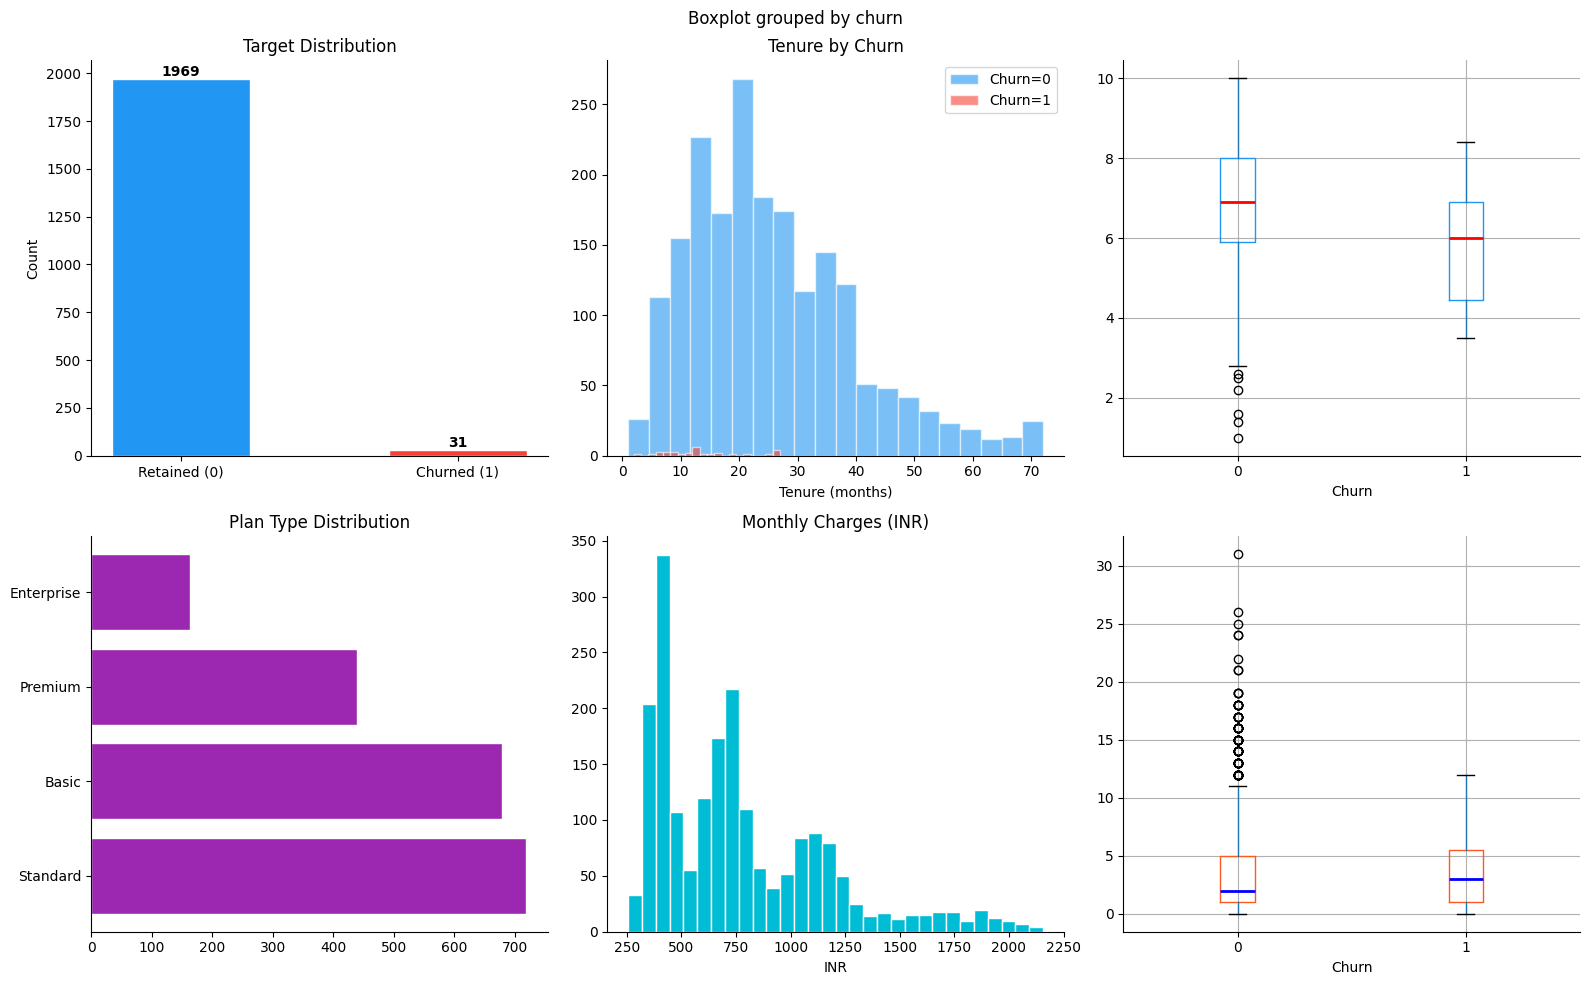

In [8]:
#Visualisations
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Task 1 – Dataset Exploration", fontsize=16, fontweight='bold')

# (a) Churn bar chart
ax = axes[0, 0]
bars = ax.bar(['Retained (0)', 'Churned (1)'], [vc[0], vc[1]],
              color=['#2196F3', '#F44336'], edgecolor='white', width=0.5)
for bar, val in zip(bars, [vc[0], vc[1]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(val), ha='center', fontweight='bold')
ax.set_title("Target Distribution"); ax.set_ylabel("Count")
ax.spines[['top','right']].set_visible(False)

# (b) Tenure by churn
ax = axes[0, 1]
for label, color in zip([0, 1], ['#2196F3', '#F44336']):
    ax.hist(df[df['churn']==label]['tenure_months'], bins=20,
            alpha=0.6, label=f'Churn={label}', color=color, edgecolor='white')
ax.set_title("Tenure by Churn"); ax.set_xlabel("Tenure (months)"); ax.legend()
ax.spines[['top','right']].set_visible(False)

# (c) Satisfaction score by churn
ax = axes[0, 2]
df.boxplot(column='satisfaction_score', by='churn', ax=ax,
           boxprops=dict(color='#2196F3'), medianprops=dict(color='red', linewidth=2))
ax.set_title("Satisfaction Score vs Churn"); ax.set_xlabel("Churn")
plt.sca(ax); plt.title("")
ax.spines[['top','right']].set_visible(False)

# (d) Plan type distribution
ax = axes[1, 0]
plan_counts = df['plan_type'].value_counts()
ax.barh(plan_counts.index, plan_counts.values, color='#9C27B0', edgecolor='white')
ax.set_title("Plan Type Distribution")
ax.spines[['top','right']].set_visible(False)

# (e) Monthly charges
ax = axes[1, 1]
ax.hist(df['monthly_charges_inr'], bins=30, color='#00BCD4', edgecolor='white')
ax.set_title("Monthly Charges (INR)"); ax.set_xlabel("INR")
ax.spines[['top','right']].set_visible(False)

# (f) Payment delay by churn
ax = axes[1, 2]
df.boxplot(column='payment_delay_days', by='churn', ax=ax,
           boxprops=dict(color='#FF5722'), medianprops=dict(color='blue', linewidth=2))
ax.set_title("Payment Delay vs Churn"); ax.set_xlabel("Churn")
plt.sca(ax); plt.title("")
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig("outputs/task1_exploration.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#Task 2

In [9]:
CAT_COLS = ['region', 'plan_type', 'contract_type', 'payment_method']
NUM_COLS = [
    'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
    'support_tickets_last_90_days', 'payment_delay_days',
    'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago',
    'discount_percent', 'autopay_enabled', 'referral_count'
]

# Step 1 – Drop identifier
df_proc = df.drop(columns=['customer_id']).copy()

# Step 2 – One-Hot Encode
df_proc = pd.get_dummies(df_proc, columns=CAT_COLS, drop_first=False)
print(f"Features after encoding: {df_proc.shape[1] - 1}")

# Step 3 – Feature / Target split
X = df_proc.drop(columns=['churn'])
y = df_proc['churn']

# Step 4 – Scale numerical features
scaler = StandardScaler()
X[NUM_COLS] = scaler.fit_transform(X[NUM_COLS])

# Step 5 – Train/Test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

# Step 6 – Class weights
neg, pos = np.bincount(y_train)
CLASS_WEIGHT = {0: 1.0, 1: neg / pos}
N_FEATURES = X_train.shape[1]

print(f"Training samples  : {X_train.shape[0]}  (churn={y_train.sum()})")
print(f"Testing  samples  : {X_test.shape[0]}  (churn={y_test.sum()})")
print(f"Input features    : {N_FEATURES}")
print(f"Class weight [1]  : {CLASS_WEIGHT[1]:.1f}x  (churn penalised 63× more)")

Features after encoding: 28
Training samples  : 1600  (churn=25)
Testing  samples  : 400  (churn=6)
Input features    : 28
Class weight [1]  : 63.0x  (churn penalised 63× more)


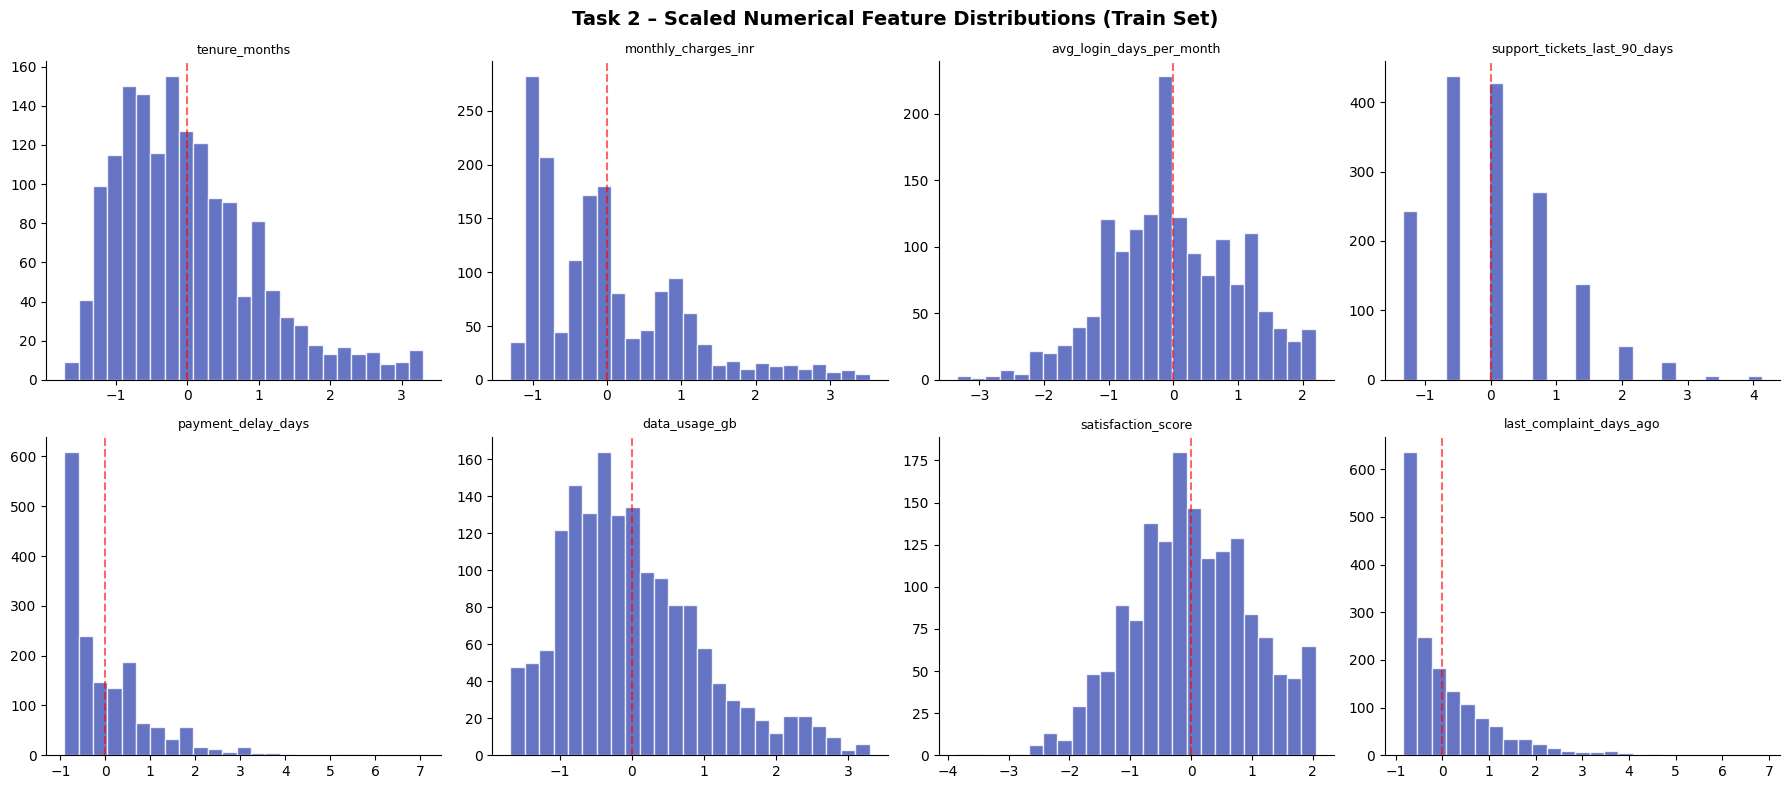

After scaling: mean ≈ 0, std ≈ 1 for all numerical features.


In [10]:
#Visualise scaled feature distribution
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Task 2 – Scaled Numerical Feature Distributions (Train Set)",
             fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), NUM_COLS[:8]):
    ax.hist(X_train[col], bins=25, color='#3F51B5', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=9)
    ax.axvline(0, color='red', linestyle='--', alpha=0.6, label='mean=0')
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig("outputs/task2_scaled_features.png", dpi=150, bbox_inches='tight')
plt.show()
print("After scaling: mean ≈ 0, std ≈ 1 for all numerical features.")

In [ ]:
#Task 3

In [11]:
def build_model(hidden_layers: list, lr: float = 0.001,
                activation: str = 'relu', dropout_rate: float = 0.3):
    """
    Build a configurable feed-forward neural network.

    Parameters
    ----------
    hidden_layers : list[int]  – neuron counts per hidden layer
    lr            : float      – Adam learning rate
    activation    : str        – hidden layer activation ('relu', 'tanh', etc.)
    dropout_rate  : float      – Dropout probability after each hidden layer
    """
    model = keras.Sequential(name="CustomerChurnNN")
    model.add(layers.Input(shape=(N_FEATURES,), name="input_layer"))

    for i, units in enumerate(hidden_layers, start=1):
        model.add(layers.Dense(units, activation=activation,
                               kernel_initializer='he_uniform',
                               name=f"hidden_{i}"))
        model.add(layers.Dropout(dropout_rate, name=f"dropout_{i}"))

    model.add(layers.Dense(1, activation='sigmoid', name="output_layer"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model


def evaluate_model(model, threshold: float = 0.5):
    """Evaluate model on test set. Returns probs, preds, cm, F1, AUC, report."""
    y_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_prob >= threshold).astype(int)
    cm     = confusion_matrix(y_test, y_pred)
    f1     = f1_score(y_test, y_pred, zero_division=0)
    auc    = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, zero_division=0)
    return y_prob, y_pred, cm, f1, auc, report


# Instantiate baseline model
baseline_model = build_model(hidden_layers=[64, 32], lr=0.001, activation='relu')
baseline_model.summary()


Model: "CustomerChurnNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,969 (15.50 KB)

 Trainable params: 3,969 (15.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Task 4

In [12]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True)

baseline_history = baseline_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.15,
    class_weight=CLASS_WEIGHT,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6772 - auc: 0.6078 - loss: 1.9586 - val_accuracy: 0.8958 - val_auc: 0.6901 - val_loss: 0.3588
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7118 - auc: 0.6596 - loss: 1.4599 - val_accuracy: 0.7542 - val_auc: 0.7447 - val_loss: 0.4934
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6846 - auc: 0.6855 - loss: 1.4188 - val_accuracy: 0.7250 - val_auc: 0.7626 - val_loss: 0.5209
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7015 - auc: 0.7589 - loss: 1.2269 - val_accuracy: 0.7083 - val_auc: 0.7941 - val_loss: 0.5148
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7088 - auc: 0.8351 - loss: 1.0338 - val_accuracy: 0.7458 - val_auc: 0.8288 - val_loss: 0.4838
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7456 - auc: 0.8274 - loss: 1.0928 - val_accuracy: 0.8292 - val_auc: 0.8624 - val_loss: 0.4113
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step -

In [13]:
#Metrics
y_prob_base, y_pred_base, cm_base, f1_base, auc_base, rpt_base = \
    evaluate_model(baseline_model)

train_acc  = baseline_history.history['accuracy'][-1]
val_acc    = baseline_history.history['val_accuracy'][-1]
train_loss = baseline_history.history['loss'][-1]
val_loss   = baseline_history.history['val_loss'][-1]

print(f"{'─'*45}")
print(f"  Training   Accuracy  : {train_acc:.4f}")
print(f"  Validation Accuracy  : {val_acc:.4f}")
print(f"  Training   Loss      : {train_loss:.4f}")
print(f"  Validation Loss      : {val_loss:.4f}")
print(f"{'─'*45}")
print(f"  Test F1-Score        : {f1_base:.4f}")
print(f"  Test ROC-AUC         : {auc_base:.4f}")
print(f"\nClassification Report:\n{rpt_base}")
print(f"Confusion Matrix:\n{cm_base}")

─────────────────────────────────────────────
  Training   Accuracy  : 0.9353
  Validation Accuracy  : 0.9708
  Training   Loss      : 0.2692
  Validation Loss      : 0.0867
─────────────────────────────────────────────
  Test F1-Score        : 0.0952
  Test ROC-AUC         : 0.7301

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.98       394
           1       0.07      0.17      0.10         6

    accuracy                           0.95       400
   macro avg       0.53      0.57      0.54       400
weighted avg       0.97      0.95      0.96       400

Confusion Matrix:
[[380  14]
 [  5   1]]


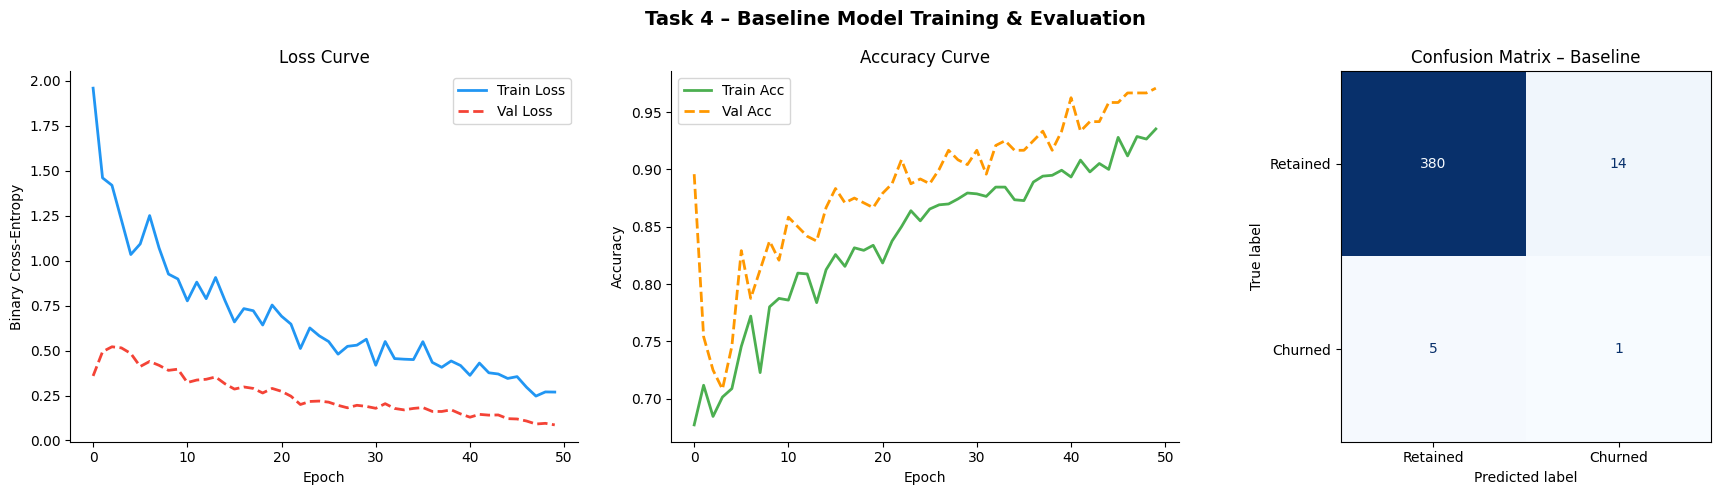

In [14]:
#Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Task 4 – Baseline Model Training & Evaluation",
             fontsize=14, fontweight='bold')

# Loss curves
ax = axes[0]
ax.plot(baseline_history.history['loss'],     label='Train Loss', color='#2196F3', lw=2)
ax.plot(baseline_history.history['val_loss'], label='Val Loss',   color='#F44336', lw=2, linestyle='--')
ax.set_title("Loss Curve"); ax.set_xlabel("Epoch"); ax.set_ylabel("Binary Cross-Entropy")
ax.legend(); ax.spines[['top','right']].set_visible(False)

# Accuracy curves
ax = axes[1]
ax.plot(baseline_history.history['accuracy'],     label='Train Acc', color='#4CAF50', lw=2)
ax.plot(baseline_history.history['val_accuracy'], label='Val Acc',   color='#FF9800', lw=2, linestyle='--')
ax.set_title("Accuracy Curve"); ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.legend(); ax.spines[['top','right']].set_visible(False)

# Confusion matrix
ax = axes[2]
ConfusionMatrixDisplay(confusion_matrix=cm_base,
                       display_labels=['Retained', 'Churned']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title("Confusion Matrix – Baseline")

plt.tight_layout()
plt.savefig("outputs/task4_training_evaluation.png", dpi=150, bbox_inches='tight')
plt.show()